Let's

1. Load the dataset
2. Plot the time series
3. Decompose it into:

   * Trend
   * Seasonality
   * Residual (noise)
4. Explain each component visually

---

## Step-by-Step Time Series Decomposition Notebook

### Step 1: Load the Airline Passengers Dataset

We'll use a well-known monthly dataset: number of international airline passengers from 1949 to 1960.

In [ ]:
import pandas as pd

# Load from URL
url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv'
df = pd.read_csv(url, parse_dates=['Month'], index_col='Month')

# Display first few rows
df.head()


,Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121






### Step 2: Plot the Original Time Series


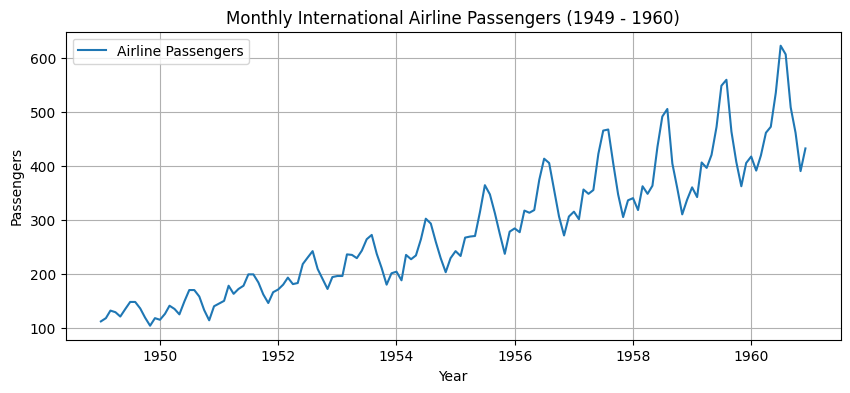

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.plot(df, label="Airline Passengers")
plt.title("Monthly International Airline Passengers (1949 - 1960)")
plt.xlabel("Year")
plt.ylabel("Passengers")
plt.grid(True)
plt.legend()
plt.show()




### Step 3: Decompose the Time Series

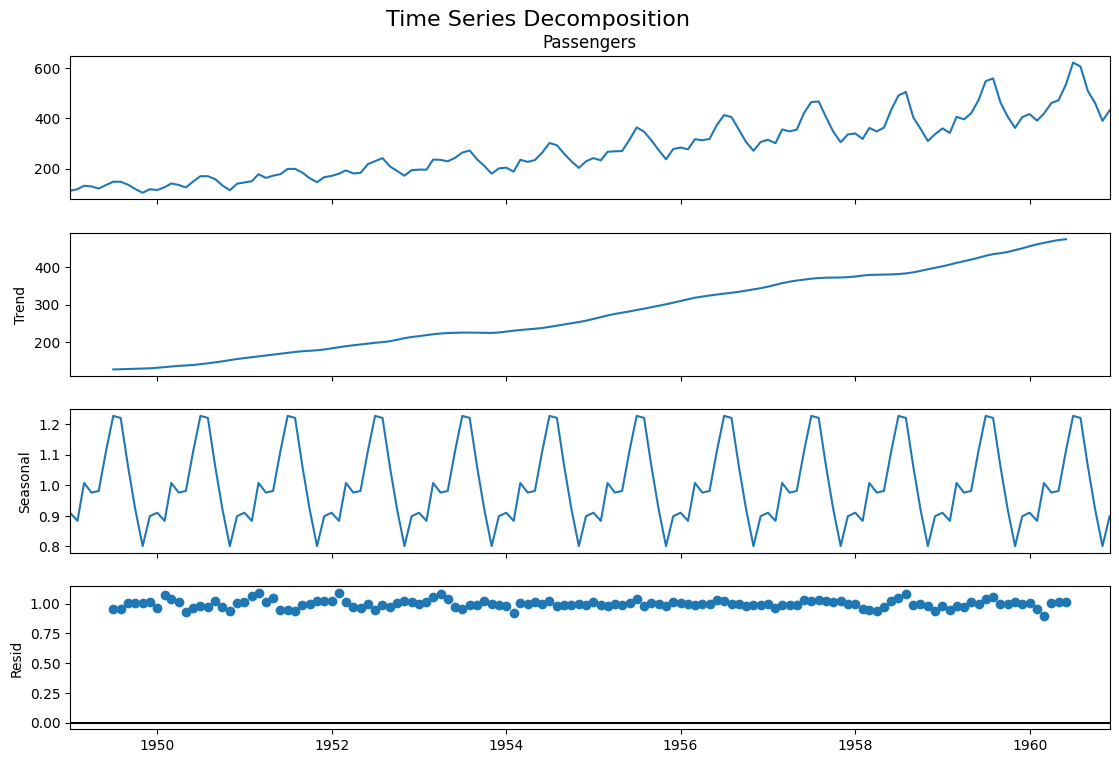

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Decompose the time series (multiplicative or additive)
decomposition = seasonal_decompose(df['Passengers'], model='multiplicative')  # or model='additive'

# Plot all components
fig = decomposition.plot()
fig.set_size_inches(12, 8)
plt.suptitle("Time Series Decomposition", fontsize=16)
plt.show()


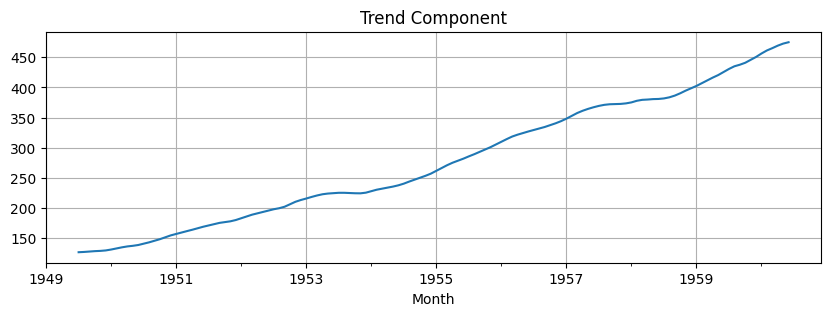

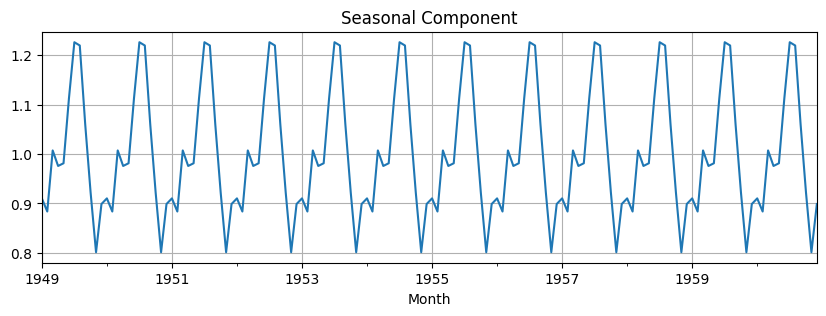

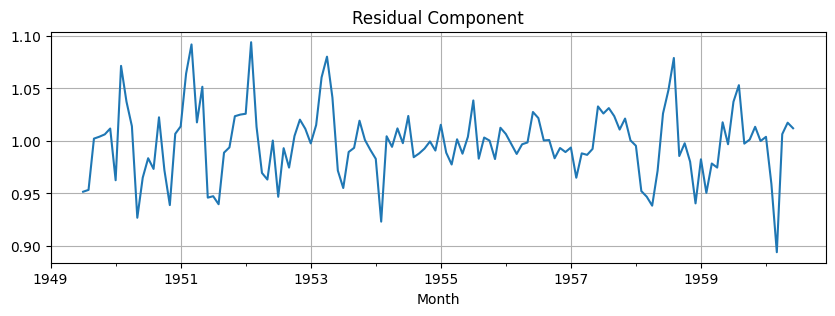

In [ ]:
# Access components
trend = decomposition.trend
seasonal = decomposition.seasonal
residual = decomposition.resid

# Plot each one
trend.plot(title="Trend Component", figsize=(10, 3))
plt.grid(); plt.show()

seasonal.plot(title="Seasonal Component", figsize=(10, 3))
plt.grid(); plt.show()

residual.plot(title="Residual Component", figsize=(10, 3))
plt.grid(); plt.show()


##  What is Naïve Forecasting?

> It assumes that the **next value is equal to the last observed value**.

This is often a **baseline** to compare more advanced methods against. We'll apply this to the **Airline Passengers dataset** and forecast the next 10 months.

---

##  Step-by-Step Forecasting with Naïve Method

In [ ]:
# Last 10 months as test set, rest as training
train = df[:-10]
test = df[-10:]

print("Train shape:", train.shape)
print("Test shape:", test.shape)


Train shape: (134, 1)
Test shape: (10, 1)


In [ ]:
# Forecast: next value = last observed training value
naive_forecast = pd.Series(
    [train['Passengers'].iloc[-1]] * len(test),
    index=test.index
)

# Show predictions
naive_forecast


,0
Month,
1960-03-01,391
1960-04-01,391
1960-05-01,391
1960-06-01,391
1960-07-01,391
1960-08-01,391
1960-09-01,391
1960-10-01,391
1960-11-01,391


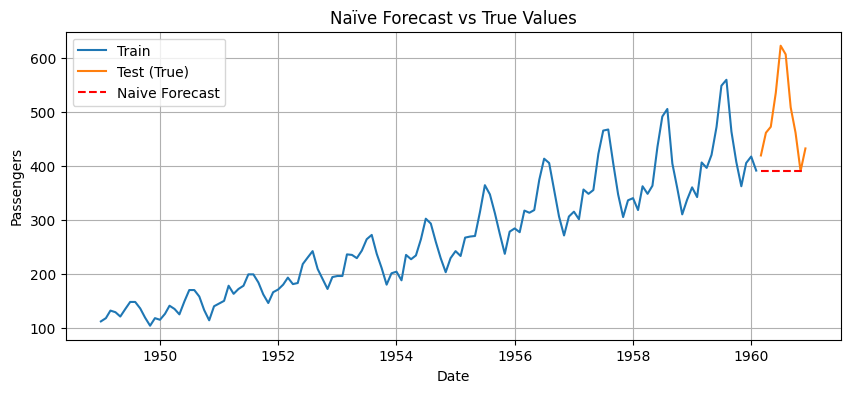

In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(train.index, train['Passengers'], label="Train")
plt.plot(test.index, test['Passengers'], label="Test (True)")
plt.plot(naive_forecast.index, naive_forecast, label="Naive Forecast", linestyle="--", color="red")

plt.title("Naïve Forecast vs True Values")
plt.xlabel("Date")
plt.ylabel("Passengers")
plt.legend()
plt.grid()
plt.show()


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(test['Passengers'], naive_forecast)
rmse = np.sqrt(mean_squared_error(test['Passengers'], naive_forecast))

print(f"📉 Mean Absolute Error (MAE): {mae:.2f}")
print(f"📉 Root Mean Squared Error (RMSE): {rmse:.2f}")


📉 Mean Absolute Error (MAE): 99.80
📉 Root Mean Squared Error (RMSE): 123.63


### Naïve Forecasting Summary

- This simple method assumes future values will be the same as the last observed value.
- It's useful as a **baseline** to assess if more complex models are doing better.
- In our case:
  - MAE ≈ 99.80
  - RMSE ≈ 123.63
- Visually, you can see the forecast is flat, which doesn't capture the trend or seasonality.


Let’s move to a more advanced yet intuitive forecasting technique: **Exponential Smoothing**.

---

## 📈 What is Exponential Smoothing?

> Exponential Smoothing assigns **exponentially decreasing weights** to past observations.
> It’s a step up from naïve forecasting and **more responsive to recent changes** in the data.

We’ll start with **Simple Exponential Smoothing (SES)** which is suitable for **non-seasonal data with no trend** — but we’ll still use it as a stepping stone on our seasonal dataset.

---

## ✅ Step-by-Step Forecasting with Exponential Smoothing


In [ ]:
from statsmodels.tsa.holtwinters import SimpleExpSmoothing


In [ ]:
# Fit Simple Exponential Smoothing model
ses_model = SimpleExpSmoothing(train['Passengers']).fit(smoothing_level=0.8, optimized=False)

# Forecast next 10 months
ses_forecast = ses_model.forecast(10)


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


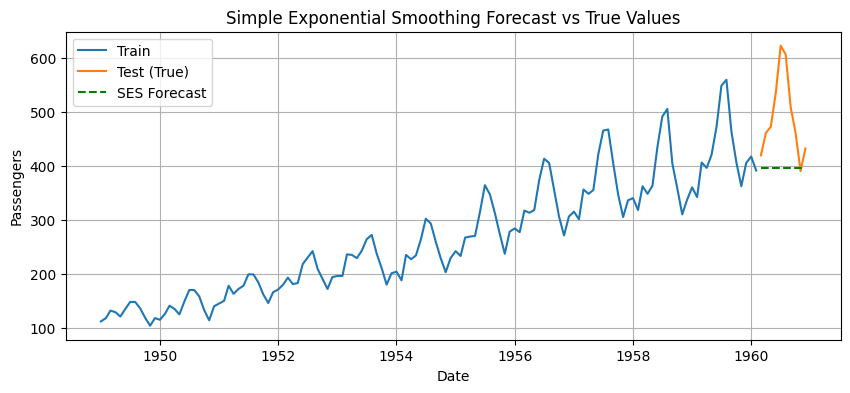

In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(train.index, train['Passengers'], label="Train")
plt.plot(test.index, test['Passengers'], label="Test (True)")
plt.plot(ses_forecast.index, ses_forecast, label="SES Forecast", linestyle="--", color="green")

plt.title("Simple Exponential Smoothing Forecast vs True Values")
plt.xlabel("Date")
plt.ylabel("Passengers")
plt.legend()
plt.grid()
plt.show()


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae_ses = mean_absolute_error(test['Passengers'], ses_forecast)
rmse_ses = np.sqrt(mean_squared_error(test['Passengers'], ses_forecast))

print(f"📉 SES Mean Absolute Error (MAE): {mae_ses:.2f}")
print(f"📉 SES Root Mean Squared Error (RMSE): {rmse_ses:.2f}")


📉 SES Mean Absolute Error (MAE): 96.22
📉 SES Root Mean Squared Error (RMSE): 120.05


### Simple Exponential Smoothing (SES)

- SES gives **more importance to recent observations** via a smoothing factor (α).
- Unlike the naïve method, SES is **not flat** — it gently adjusts to the trend.
- In this case:
  - MAE ≈ 96.22
  - RMSE ≈ 120.05
- You’ll notice that it slightly tracks the upward movement better than the naïve forecast.
- However, since this data has **clear seasonality**, SES still isn’t ideal for long-term forecasting.


Now let's move to a classical statistical modeling technique for time series: the **Autoregressive (AR) model**.

---

## 📘 What is an AR Model?

> An **Autoregressive (AR)** model predicts future values based on **a linear combination of past values**.

Mathematically:

$$
y_t = c + \phi_1 y_{t-1} + \phi_2 y_{t-2} + \dots + \phi_p y_{t-p} + \varepsilon_t
$$

Where:

* $y_t$ is the value at time *t*
* $\phi_i$ are coefficients
* $p$ is the **order** of the AR model
* $\varepsilon_t$ is white noise

---

## ✅ Step-by-Step Forecasting with AR Model

In [ ]:
from statsmodels.tsa.ar_model import AutoReg


In [ ]:
# Fit an AR model of order p (we'll start with p=5 as an example)
p = 5
ar_model = AutoReg(train['Passengers'], lags=p).fit()

# Forecast the next 10 steps
ar_forecast = ar_model.predict(start=len(train), end=len(train) + len(test) - 1, dynamic=False)


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/deterministic.py:308: UserWarning: Only PeriodIndexes, DatetimeIndexes with a frequency set, RangesIndexes, and Index with a unit increment support extending. The index is set will contain the position relative to the data length.
  fcast_index = self._extend_index(index, steps, forecast_index)


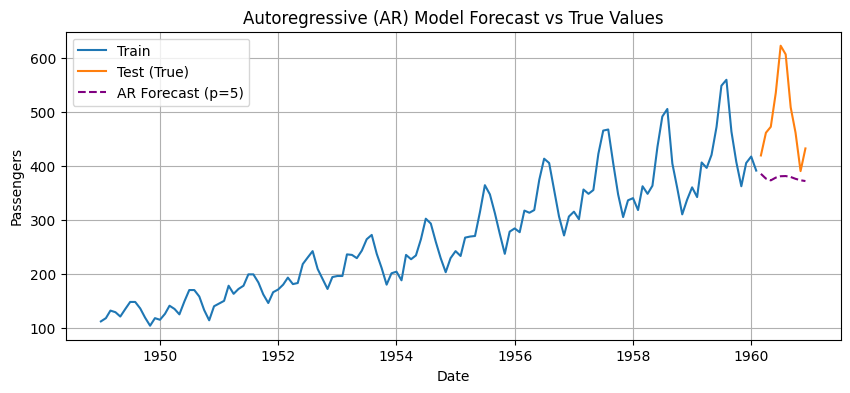

In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(train.index, train['Passengers'], label="Train")
plt.plot(test.index, test['Passengers'], label="Test (True)")
plt.plot(ar_forecast.index, ar_forecast, label="AR Forecast (p=5)", linestyle="--", color="purple")

plt.title("Autoregressive (AR) Model Forecast vs True Values")
plt.xlabel("Date")
plt.ylabel("Passengers")
plt.legend()
plt.grid()
plt.show()


In [ ]:
mae_ar = mean_absolute_error(test['Passengers'], ar_forecast)
rmse_ar = np.sqrt(mean_squared_error(test['Passengers'], ar_forecast))

print(f"📉 AR Model MAE: {mae_ar:.2f}")
print(f"📉 AR Model RMSE: {rmse_ar:.2f}")


📉 AR Model MAE: 113.29
📉 AR Model RMSE: 134.01


### Autoregressive (AR) Forecasting

- AR models assume that future values are **linearly dependent on past values**.
- You specify the **number of lags (p)** to include — this can be selected via AIC/BIC or trial-and-error.
- In our case:
  - MAE ≈ 113.29
  - RMSE ≈ 134.01
- AR performs better than naïve or exponential smoothing on **stationary, trend-dominated data**.
- However, AR **does not inherently model seasonality** — making it suboptimal for strongly seasonal data like this airline passenger series.


In [ ]:
from statsmodels.tsa.arima.model import ARIMA


In [ ]:
# Define MA model as ARIMA(0, 0, q)
q = 5  # MA lag order
ma_model = ARIMA(train['Passengers'], order=(0, 0, q)).fit()

# Forecast the next 10 months
ma_forecast = ma_model.forecast(steps=10)


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals

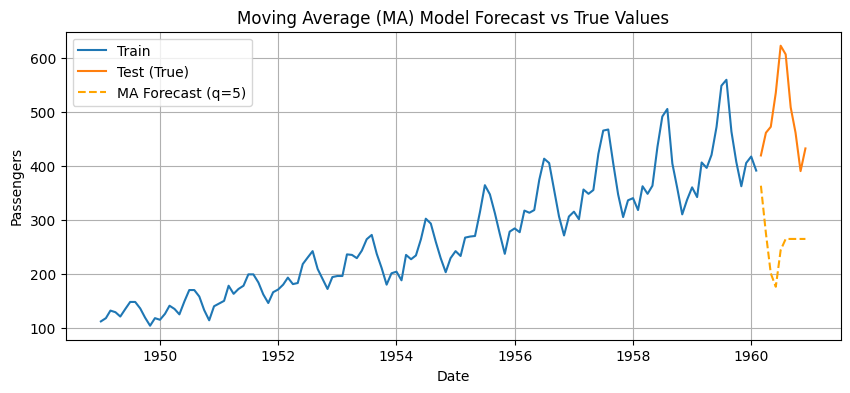

In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(train.index, train['Passengers'], label="Train")
plt.plot(test.index, test['Passengers'], label="Test (True)")
plt.plot(ma_forecast.index, ma_forecast, label="MA Forecast (q=5)", linestyle="--", color="orange")

plt.title("Moving Average (MA) Model Forecast vs True Values")
plt.xlabel("Date")
plt.ylabel("Passengers")
plt.legend()
plt.grid()
plt.show()


In [ ]:
mae_ma = mean_absolute_error(test['Passengers'], ma_forecast)
rmse_ma = np.sqrt(mean_squared_error(test['Passengers'], ma_forecast))

print(f"📉 MA Model MAE: {mae_ma:.2f}")
print(f"📉 MA Model RMSE: {rmse_ma:.2f}")


📉 MA Model MAE: 232.46
📉 MA Model RMSE: 253.25


### Moving Average (MA) Forecasting

- Unlike SMA (Simple Moving Average), MA model here is a **statistical model using past forecast errors**.
- MA models are good for **capturing noise patterns**, not trend or seasonality.
- In this case:
  - MAE ≈ 232.46
  - RMSE ≈ 253.25
- MA models often perform well on **stationary data with short memory**, but aren’t ideal for **long-term structure** like upward trends or seasonal spikes.
